In [323]:
Subject='P1'
# 选择并绘制第一环节生成的健康侧脚踝 mocap 重力方向加速度信号
MOCAP_SUBJECT = f'{Subject}'
MOCAP_CANE_CONDITION = 'without_cane'  # 可选 'with_cane' 或 'without_cane'
MOCAP_SIGNAL_INDEX = 0              # 选择下方列出的对应文件
MOCAP_X_RANGE = None    # 例如 (7, 20)；None 表示显示全部时间
PEAK_MIN_DISTANCE_S = 1  # 相邻候选峰的最小时间间隔（秒）

In [324]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

FS = 100
DATA_DIR = Path('/mnt/ssd1/wyc/my_projects/SHRED/SHRED/Dataset_Stroke/Yan_Stroke Experiment Data')
gravity_filter_path = DATA_DIR / f'Data_for_Align/IMU/{Subject}_GravityFilter.csv'
if not gravity_filter_path.exists():
    raise FileNotFoundError(
        f'未找到 {gravity_filter_path}，请先运行 Process copy525 _without_gait.ipynb。'
    )
display_columns = [
    'elapsed (s)',
    'S1_linacc_gravity_filtered',
    'S2_linacc_gravity_filtered',
    'S6_linacc_gravity_filtered',
]
df = pd.read_csv(gravity_filter_path, usecols=display_columns)
print(f'已加载重力补偿数据: {gravity_filter_path.name}')


def _sorted_time_range(time_range, fallback_time):
    fallback_time = np.asarray(fallback_time, dtype=float)
    if time_range is None:
        return float(np.nanmin(fallback_time)), float(np.nanmax(fallback_time))
    if len(time_range) != 2:
        raise ValueError('时间范围必须是 (start, end) 形式。')
    return tuple(sorted(map(float, time_range)))


def _minimum_peak_distance_samples(time_values, min_distance_s):
    finite_time = np.asarray(time_values, dtype=float)
    finite_time = finite_time[np.isfinite(finite_time)]
    finite_time_steps = np.diff(finite_time)
    finite_time_steps = finite_time_steps[finite_time_steps > 0]
    if len(finite_time_steps) == 0:
        raise ValueError('时间轴中没有有效的递增采样点。')
    sample_interval_s = float(np.median(finite_time_steps))
    return max(1, int(round(min_distance_s / sample_interval_s)))


def _candidate_peak_indices(time_values, signal_values, x_range, min_distance_s):
    time_values = np.asarray(time_values, dtype=float)
    signal_values = np.asarray(signal_values, dtype=float)
    x_min, x_max = _sorted_time_range(x_range, time_values)
    search_mask = (
        np.isfinite(time_values)
        & np.isfinite(signal_values)
        & (time_values >= x_min)
        & (time_values <= x_max)
    )
    search_indices = np.flatnonzero(search_mask)
    if len(search_indices) < 3:
        return np.array([], dtype=int), x_min, x_max
    minimum_peak_distance = _minimum_peak_distance_samples(time_values, min_distance_s)
    relative_peaks, _ = find_peaks(
        signal_values[search_indices], distance=minimum_peak_distance
    )
    return search_indices[relative_peaks], x_min, x_max


def _earliest_peak_indices(time_values, signal_values, x_range, n_peaks=5, min_distance_s=0.3):
    candidate_peak_indices, x_min, x_max = _candidate_peak_indices(
        time_values, signal_values, x_range, min_distance_s
    )
    if len(candidate_peak_indices) == 0:
        return candidate_peak_indices, x_min, x_max
    time_values = np.asarray(time_values, dtype=float)
    earliest_peak_indices = candidate_peak_indices[
        np.argsort(time_values[candidate_peak_indices])[:n_peaks]
    ]
    return earliest_peak_indices, x_min, x_max


def _first_last_peak_indices(time_values, signal_values, x_range, min_distance_s=0.3):
    candidate_peak_indices, x_min, x_max = _candidate_peak_indices(
        time_values, signal_values, x_range, min_distance_s
    )
    if len(candidate_peak_indices) == 0:
        return candidate_peak_indices, x_min, x_max
    time_values = np.asarray(time_values, dtype=float)
    candidate_peak_indices = candidate_peak_indices[np.argsort(time_values[candidate_peak_indices])]
    if len(candidate_peak_indices) == 1:
        return candidate_peak_indices, x_min, x_max
    return np.array([candidate_peak_indices[0], candidate_peak_indices[-1]], dtype=int), x_min, x_max


def _annotate_peak(ax, peak_time, peak_value, label, color='crimson', marker='v', y_offset=14):
    ax.scatter(peak_time, peak_value, color=color, marker=marker, s=55, zorder=5)
    ax.annotate(
        f'{label}\nTime = {peak_time:.3f} s',
        xy=(peak_time, peak_value),
        xytext=(0, y_offset),
        textcoords='offset points', ha='center', va='bottom',
        color=color, fontsize=9,
        arrowprops={'arrowstyle': '->', 'color': color, 'lw': 0.8},
    )

已加载重力补偿数据: P1_GravityFilter.csv


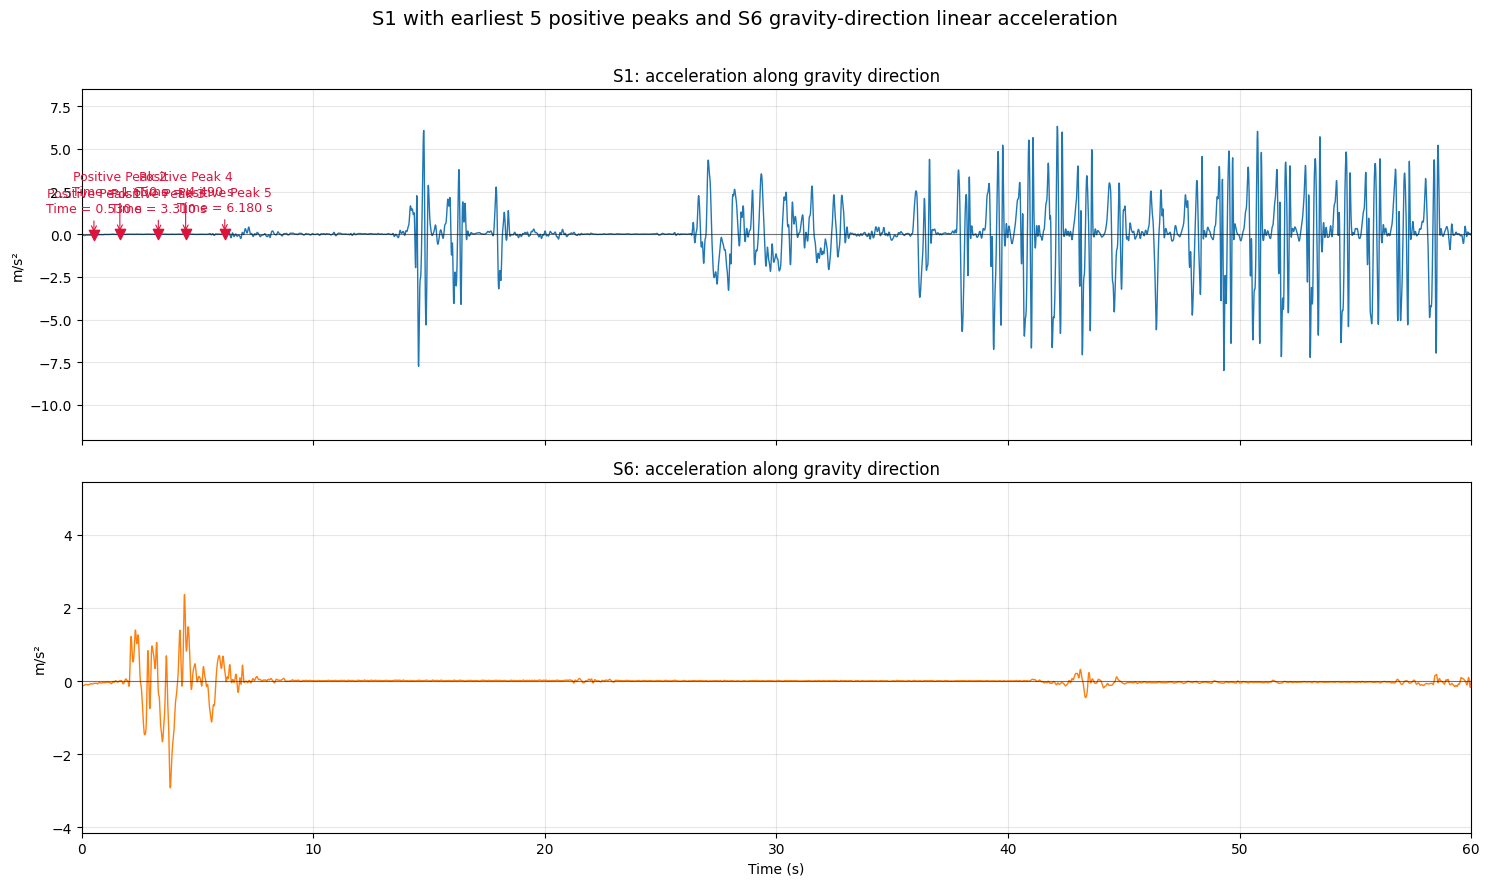

S1: x 轴范围 [0.000, 60.000] s 内最早出现的 5 个正峰值：
  Peak 1: Time=0.530 s, Acceleration=-0.0374 m/s²
  Peak 2: Time=1.650 s, Acceleration=0.0134 m/s²
  Peak 3: Time=3.310 s, Acceleration=0.0061 m/s²
  Peak 4: Time=4.490 s, Acceleration=0.0098 m/s²
  Peak 5: Time=6.180 s, Acceleration=0.0375 m/s²


In [325]:
# 展示 S1/S2（带峰值标注）和 S6（无标注）在瞬时重力方向上的线性加速度
plot_sensors = ['S1', 'S6']  # 将第一个传感器改为 'S1' 或 'S2'；S6 保留用于对照显示（无峰值标注）
IMU_PEAK_MIN_DISTANCE_S = PEAK_MIN_DISTANCE_S  # S1/S2 两个峰值的最小间隔时间（秒）
IMU_PEAK_POLARITY = 'positive'  # 可选 'positive' 检测正峰值，或 'negative' 检测负峰值
gravity_columns = [f'{sensor}_linacc_gravity_filtered' for sensor in plot_sensors]
missing_columns = [column for column in gravity_columns if column not in df.columns]
if missing_columns:
    raise KeyError(f'缺少重力方向加速度列，请先运行上一个重力补偿单元: {missing_columns}')

selected_peak_sensors = [sensor for sensor in plot_sensors if sensor in {'S1', 'S2'}]
if len(selected_peak_sensors) != 1:
    raise ValueError("plot_sensors 中请只选择一个待检测传感器：'S1' 或 'S2'，并保留 'S6' 用于无标注显示。")
selected_peak_sensor = selected_peak_sensors[0]
IMU_PEAK_POLARITY = str(IMU_PEAK_POLARITY).strip().lower()
if IMU_PEAK_POLARITY not in {'positive', 'negative'}:
    raise ValueError("IMU_PEAK_POLARITY 必须是 'positive' 或 'negative'。")
peak_polarity_label = '正峰值' if IMU_PEAK_POLARITY == 'positive' else '负峰值'
peak_polarity_plot_label = 'Positive Peak' if IMU_PEAK_POLARITY == 'positive' else 'Negative Peak'
peak_polarity_title_label = 'positive peaks' if IMU_PEAK_POLARITY == 'positive' else 'negative peaks'

if 'elapsed (s)' in df.columns:
    plot_time = df['elapsed (s)'].to_numpy(dtype=float)
    x_label = 'Time (s)'
else:
    plot_time = np.arange(len(df), dtype=float) / FS
    x_label = 'Time (s, derived from sample index)'

fig, axes = plt.subplots(len(plot_sensors), 1, figsize=(15, 9), sharex=True)
axes = np.atleast_1d(axes)
colors = ['tab:blue', 'tab:orange', 'tab:green']
axis_by_sensor = {}
signal_by_sensor = {}
for ax, sensor, column, color in zip(axes, plot_sensors, gravity_columns, colors):
    signal_values = df[column].to_numpy(dtype=float)
    axis_by_sensor[sensor] = ax
    signal_by_sensor[sensor] = signal_values
    ax.plot(plot_time, signal_values, color=color, linewidth=1.0)
    ax.axhline(0.0, color='black', linewidth=0.8, alpha=0.5)
    ax.set_title(f'{sensor}: acceleration along gravity direction')
    ax.set_ylabel('m/s²')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel(x_label)
axes[-1].set_xlim(0,60)  # 调整这里的起止时间（秒）来设置 x 轴范围
imu_x_min, imu_x_max = axes[-1].get_xlim()

selected_signal_values = signal_by_sensor[selected_peak_sensor]
peak_detection_signal = selected_signal_values if IMU_PEAK_POLARITY == 'positive' else -selected_signal_values
peak_indices, _, _ = _earliest_peak_indices(
    plot_time,
    peak_detection_signal,
    (imu_x_min, imu_x_max),
    n_peaks=5,
    min_distance_s=IMU_PEAK_MIN_DISTANCE_S,
)
peak_ax = axis_by_sensor[selected_peak_sensor]
peak_marker = 'v' if IMU_PEAK_POLARITY == 'positive' else '^'
for rank, peak_index in enumerate(peak_indices, start=1):
    _annotate_peak(
        peak_ax,
        plot_time[peak_index],
        selected_signal_values[peak_index],
        f'{peak_polarity_plot_label} {rank}',
        color='crimson',
        marker=peak_marker,
        y_offset=14 + 12 * ((rank - 1) % 2),
    )

fig.suptitle(f'{selected_peak_sensor} with earliest 5 {peak_polarity_title_label} and S6 gravity-direction linear acceleration', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

if len(peak_indices) == 0:
    print(f'{selected_peak_sensor}: 在 x 轴范围 [{imu_x_min:.3f}, {imu_x_max:.3f}] s 内未检测到{peak_polarity_label}。')
else:
    print(f'{selected_peak_sensor}: x 轴范围 [{imu_x_min:.3f}, {imu_x_max:.3f}] s 内最早出现的 5 个{peak_polarity_label}：')
    signal_values = selected_signal_values
    for rank, peak_index in enumerate(peak_indices, start=1):
        print(
            f'  Peak {rank}: Time={plot_time[peak_index]:.3f} s, '
            f'Acceleration={signal_values[peak_index]:.4f} m/s²'
        )


可选 mocap 信号：subject=P1, condition=without_cane
  0: P1_without_cane_hemi010201_healthy_L_toe_gravity_acceleration.csv
  1: P1_without_cane_hemi010202_healthy_L_toe_gravity_acceleration.csv
  2: P1_without_cane_hemi010203_healthy_L_toe_gravity_acceleration.csv
  3: P1_without_cane_hemi010204_healthy_L_toe_gravity_acceleration.csv
  4: P1_without_cane_hemi010205_healthy_L_toe_gravity_acceleration.csv
已选择: P1_without_cane_hemi010201_healthy_L_toe_gravity_acceleration.csv | without cane | with_cane=False


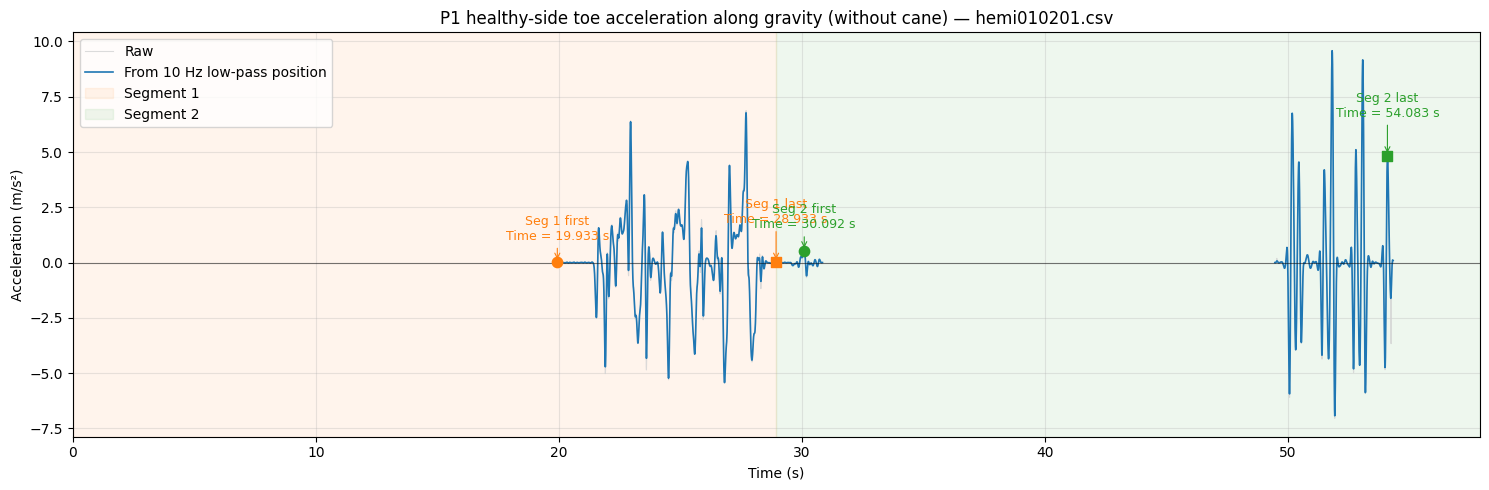

mocap 两段数据各自的首尾峰值：
  Segment 1 [0.000, 28.946] s:
    first peak: Time=19.933 s, Acceleration=0.0191 m/s²
    last peak: Time=28.933 s, Acceleration=0.0184 m/s²
  Segment 2 [28.946, 57.892] s:
    first peak: Time=30.092 s, Acceleration=0.5386 m/s²
    last peak: Time=54.083 s, Acceleration=4.8332 m/s²


In [326]:
from scipy.signal import find_peaks

valid_cane_conditions = {'with_cane', 'without_cane'}
if MOCAP_CANE_CONDITION not in valid_cane_conditions:
    raise ValueError(f'MOCAP_CANE_CONDITION 必须是 {sorted(valid_cane_conditions)}')

mocap_signal_dir = DATA_DIR / 'Data_for_Align/Mocap'
signal_pattern = (
    f'{MOCAP_SUBJECT}_{MOCAP_CANE_CONDITION}_*_toe_gravity_acceleration.csv'
)
available_mocap_signals = sorted(mocap_signal_dir.glob(signal_pattern))
if not available_mocap_signals:
    raise FileNotFoundError(
        f'未找到 {MOCAP_SUBJECT} / {MOCAP_CANE_CONDITION} 的 mocap 信号；'
        '请检查 Data_for_Align 或运行 Process525_mocap_all_subjects_gravity_acceleration.ipynb。'
    )

print(f'可选 mocap 信号：subject={MOCAP_SUBJECT}, condition={MOCAP_CANE_CONDITION}')
for index, path in enumerate(available_mocap_signals):
    print(f'  {index}: {path.name}')
if not 0 <= MOCAP_SIGNAL_INDEX < len(available_mocap_signals):
    raise IndexError(
        f'MOCAP_SIGNAL_INDEX={MOCAP_SIGNAL_INDEX} 超出范围 0-{len(available_mocap_signals) - 1}'
    )

selected_mocap_path = available_mocap_signals[MOCAP_SIGNAL_INDEX]
mocap_signal = pd.read_csv(selected_mocap_path)
selected_condition = str(mocap_signal['cane_condition'].iloc[0])
with_cane_value = mocap_signal['with_cane'].iloc[0]
uses_cane = str(with_cane_value).strip().lower() in {'true', '1'}
if selected_condition != MOCAP_CANE_CONDITION:
    raise ValueError(
        f'文件 condition={selected_condition} 与选择的 {MOCAP_CANE_CONDITION} 不一致'
    )
condition_label = 'with cane' if uses_cane else 'without cane'
print(f'已选择: {selected_mocap_path.name} | {condition_label} | with_cane={uses_cane}')
time_s = mocap_signal['time_s'].to_numpy(dtype=float)
raw_acceleration = mocap_signal['healthy_toe_gravity_acceleration_m_s2'].to_numpy(dtype=float)
filtered_acceleration = mocap_signal['healthy_toe_gravity_acceleration_filtered_m_s2'].to_numpy(dtype=float)

# mocap：把当前显示范围自动分成两段，并分别检测首峰和尾峰
x_min, x_max = _sorted_time_range(MOCAP_X_RANGE, time_s)
split_time = (x_min + x_max) / 2
mocap_segment_ranges = [(x_min, split_time), (split_time, x_max)]

mocap_peak_records = []

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(time_s, raw_acceleration, color='lightgray', linewidth=0.8, alpha=0.8, label='Raw')
ax.plot(time_s, filtered_acceleration, color='tab:blue', linewidth=1.2, label='From 10 Hz low-pass position')
ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax.set_title(
    f'{MOCAP_SUBJECT} healthy-side toe acceleration along gravity '
    f'({condition_label}) — {mocap_signal["source_file"].iloc[0]}'
)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Acceleration (m/s²)')
ax.grid(True, alpha=0.3)
segment_colors = ['tab:orange', 'tab:green']
for segment_number, (segment_range, segment_color) in enumerate(zip(mocap_segment_ranges, segment_colors), start=1):
    segment_x_min, segment_x_max = segment_range
    ax.axvspan(segment_x_min, segment_x_max, color=segment_color, alpha=0.08, label=f'Segment {segment_number}')
    first_last_indices, _, _ = _first_last_peak_indices(
        time_s, filtered_acceleration, (segment_x_min, segment_x_max),
        min_distance_s=PEAK_MIN_DISTANCE_S,
    )
    if len(first_last_indices) == 0:
        mocap_peak_records.append({
            'segment': segment_number,
            'range': (segment_x_min, segment_x_max),
            'position': None,
            'index': None,
        })
        continue
    if len(first_last_indices) == 1:
        peak_positions = ['first/last']
    else:
        peak_positions = ['first', 'last']
    for position_number, (peak_position, peak_index) in enumerate(zip(peak_positions, first_last_indices), start=1):
        peak_time = time_s[peak_index]
        peak_value = filtered_acceleration[peak_index]
        peak_marker = 'o' if peak_position.startswith('first') else 's'
        _annotate_peak(
            ax,
            peak_time,
            peak_value,
            f'Seg {segment_number} {peak_position}',
            color=segment_color,
            marker=peak_marker,
            y_offset=14 + 12 * ((position_number - 1) % 2),
        )
        mocap_peak_records.append({
            'segment': segment_number,
            'range': (segment_x_min, segment_x_max),
            'position': peak_position,
            'index': int(peak_index),
        })
ax.legend()
ax.set_xlim(x_min, x_max)
fig.tight_layout()
plt.show()

print('mocap 两段数据各自的首尾峰值：')
for segment_number, segment_range in enumerate(mocap_segment_ranges, start=1):
    segment_records = [record for record in mocap_peak_records if record['segment'] == segment_number]
    segment_x_min, segment_x_max = segment_range
    valid_records = [record for record in segment_records if record['index'] is not None]
    if not valid_records:
        print(f'  Segment {segment_number} [{segment_x_min:.3f}, {segment_x_max:.3f}] s: 未检测到局部峰值')
        continue
    print(f'  Segment {segment_number} [{segment_x_min:.3f}, {segment_x_max:.3f}] s:')
    for record in valid_records:
        peak_index = record['index']
        print(
            f"    {record['position']} peak: Time={time_s[peak_index]:.3f} s, "
            f'Acceleration={filtered_acceleration[peak_index]:.4f} m/s²'
        )
